In [2]:
import matplotlib
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import os
import glob
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy.stats import norm


In [3]:
filename = r"Declan_LYSO_GGAG3x3x27on_NUVMT_47V_thresholdscan_10April2025_20mV.csv" 
filename = r"Declan_LYSO3x3x27on_NUVMT_47V_thresholdscan_April2025_20mV.csv"

column_map = {
    "MEAS1":"ch4_min",
    "MEAS2":"ch4_area",
    "MEAS3":"ch5_min",
    "MEAS4":"ch5_area",
    "MEAS5":"ch3_fall_time",
    "MEAS6":"ch6_fall_time",
    "MEAS7":"ch36_delay_time",
    "MEAS8":"ch3_rms",
    "MEAS9":"ch6_rms",
    "MEAS10":"ch1_area"
}
df = pd.read_csv(filename)
df = df.rename(columns = column_map)
df[["ch4_area","ch5_area","ch1_area"]] *= 1e9 # Change to +nV.s
df[["ch4_area","ch5_area","ch1_area"]] = df[["ch4_area","ch5_area","ch1_area"]].abs()
df[["ch4_min","ch5_min"]] *= 1e3 # Change to +mV
df[["ch3_fall_time","ch6_fall_time","ch36_delay_time"]] *= 1e12 # Change to ps

df.head()

,ch4_min,ch4_area,ch5_min,ch5_area,ch3_fall_time,ch6_fall_time,ch36_delay_time,ch3_rms,ch6_rms,ch1_area,MEAS12,MEAS13,MEAS14,MEAS15,MEAS16,MEAS17,MEAS18,MEAS19,MEAS20
0,-529.96875,38.916405,-468.84375,34.002954,225.934976,249.440699,-155.726620,0.001262,0.001400,0.168384,9.910000e+37,9.910000e+37,-0.001463,0.001254,-0.002019,7.116717e-11,9.910000e+37,0.001342,9.910000e+37
1,-529.96875,38.916405,-468.84375,16.115024,1378.836341,213.708870,-405.921408,0.001445,0.001742,0.127666,9.910000e+37,9.910000e+37,-0.001422,0.001148,-0.001841,4.112751e-11,9.910000e+37,0.001403,9.910000e+37
2,-386.46875,27.138988,-235.46875,16.115024,1378.836341,213.708870,-405.921408,0.001445,0.001742,0.127666,9.910000e+37,9.910000e+37,-0.001422,0.001148,-0.001841,4.112751e-11,9.910000e+37,0.001403,9.910000e+37
3,-586.28125,42.674831,-451.46875,33.753223,173.341770,156.799246,-141.686158,0.001176,0.001828,0.170377,9.910000e+37,9.910000e+37,-0.001553,0.001083,-0.001813,6.503833e-11,9.910000e+37,0.001135,9.910000e+37
4,-442.28125,32.096615,-460.65625,33.738283,198.504117,280.746444,-97.817996,0.015804,0.001883,0.131121,9.910000e+37,9.910000e+37,-0.001412,0.001388,-0.001772,7.613918e-11,9.910000e+37,0.001446,9.910000e+37


# Scope measurements
|Meas#|Ch|Branch|Val|Units|
|---|---|---|---|---|
|1|4|Energy|Minimum|mV|
|2|4|Energy|Area|nV.s|
|3|5|Energy|Minimum|mV|
|4|5|Energy|Area|nV.s|
|5|3|Time|Fall time|ps|
|6|6|Time|Fall time|ps|
|7|6/3|Time|Delay time|ps|
|8|3|Time|RMS|mV|
|9|6|Time|RMS|mV|
|10|1|Energy|Area|nV.s|


59536
19669
19669
36.72777334594719
33.98513502709945
37.08224075667366 1.6851717410698865
34.331323323696175 1.5845556511400554
4088


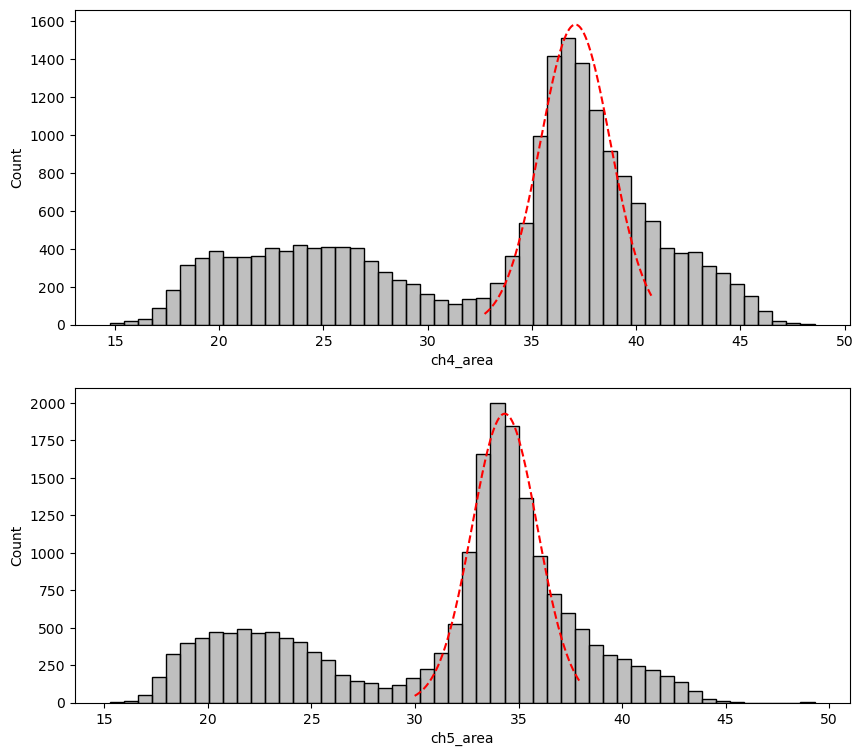

In [4]:
# from plot_utils import set_plot_style

# set_plot_style(cmap_name = "bone")
print(len(df))
dff = df.copy()
# Filter out areas that are too large
dff = dff[(dff["ch4_area"]<50)&(dff["ch5_area"]<50)]
# dff = dff[(dff["ch5_area"]>30)&(dff["ch5_area"]<40)]
# dff = dff[(dff["ch4_area"]>18)&(dff["ch5_area"]<40)]

# dff = dff[(dff["ch4_min"]>100)&(dff["ch4_min"]<550)]
# dff = dff[(dff["ch5_min"]>100)&(dff["ch5_min"]<520)]

# Filter out delay times that are too large
dff = dff[(np.abs(dff["ch36_delay_time"])<2000)]

# Filter out saturated fall times THIS IS THE RISE TIME
dff = dff[(dff["ch3_fall_time"]<400)&(dff["ch6_fall_time"]<400)]
# dff = dff[(dff["ch3_fall_time"]<1000)&(dff["ch3_fall_time"]<600)&(dff["ch6_fall_time"]<1000)&(dff["ch6_fall_time"]>160)]

# Filter out noise via rms
dff = dff[(dff["ch3_rms"]<0.0022)&(dff["ch3_rms"]>0.001)]
dff = dff[(dff["ch6_rms"]<0.0022)&(dff["ch6_rms"]>0.001)]
print(len(dff))

window = 8

fig, axes = plt.subplots(2,1, figsize = (10,9))
# sns.histplot(dff["ch4_area"], stat = 'density', kde = True, ax = axes[0])
# sns.histplot(dff["ch5_area"], stat = 'density', kde = True, ax = axes[1])
# plt.show()

# Photopeak cut
photo_cut = dff.copy()
print(len(photo_cut))

sigmas = []
mus = []
labels = ["ch4_area","ch5_area"]
for i,data in enumerate([photo_cut["ch4_area"], photo_cut["ch5_area"]]):
    # Histogram the data for fitting (not plotting)
    num_bins = 50
    counts, bin_edges = np.histogram(data, bins=num_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Peak position
    xp = bin_centers[np.argmax(counts)]
    print(xp)
    lim_left = xp - window/2
    lim_right = xp + window/2

    # Step 1: Isolate the photopeak region (manually or by peak finding)
    peak_region = (bin_centers > lim_left) & (bin_centers < lim_right)
    x_peak = bin_centers[peak_region]
    y_peak = counts[peak_region]

    # Step 2: Fit a Gaussian to the peak region
    popt, _ = norm.fit(np.repeat(x_peak, y_peak.astype(int)))  # approximate fit
    mu, std = popt, np.std(np.repeat(x_peak, y_peak.astype(int)))
    mus.append(mu)
    sigmas.append(std)

    fwhm = 2.355 * std

    # Step 3: Plot everything
    sns.histplot(data, bins=num_bins, stat='count', color='gray', edgecolor='black', alpha=0.5, ax = axes[i])

    axes[i].vlines([lim_left, xp, lim_right],0,max(counts)/(sum(counts)*(bin_edges[1]-bin_edges[0])), color = "r")

    # Overlay the fit
    x_fit = np.linspace(lim_left, lim_right, 500)
    y_fit = norm.pdf(x_fit, mu, std) * sum(y_peak) * (bin_edges[1]-bin_edges[0])
    # if i > 0:
    axes[i].plot(x_fit, y_fit, 'r--', label=f'Gaussian Fit\nμ={mu:.2f}, σ={std:.2f}, FWHM={fwhm:.2f}')

n_sigmas = 1.5

for mu,sigma,label in zip(mus,sigmas,labels):
    print(mu,sigma)
    photo_cut = photo_cut[np.abs(photo_cut[label]-mu)<=sigma*n_sigmas]
print(len(photo_cut))
plt.savefig("LYSO_LYSO_energy.svg")
plt.show()

19395


<Figure size 640x480 with 0 Axes>

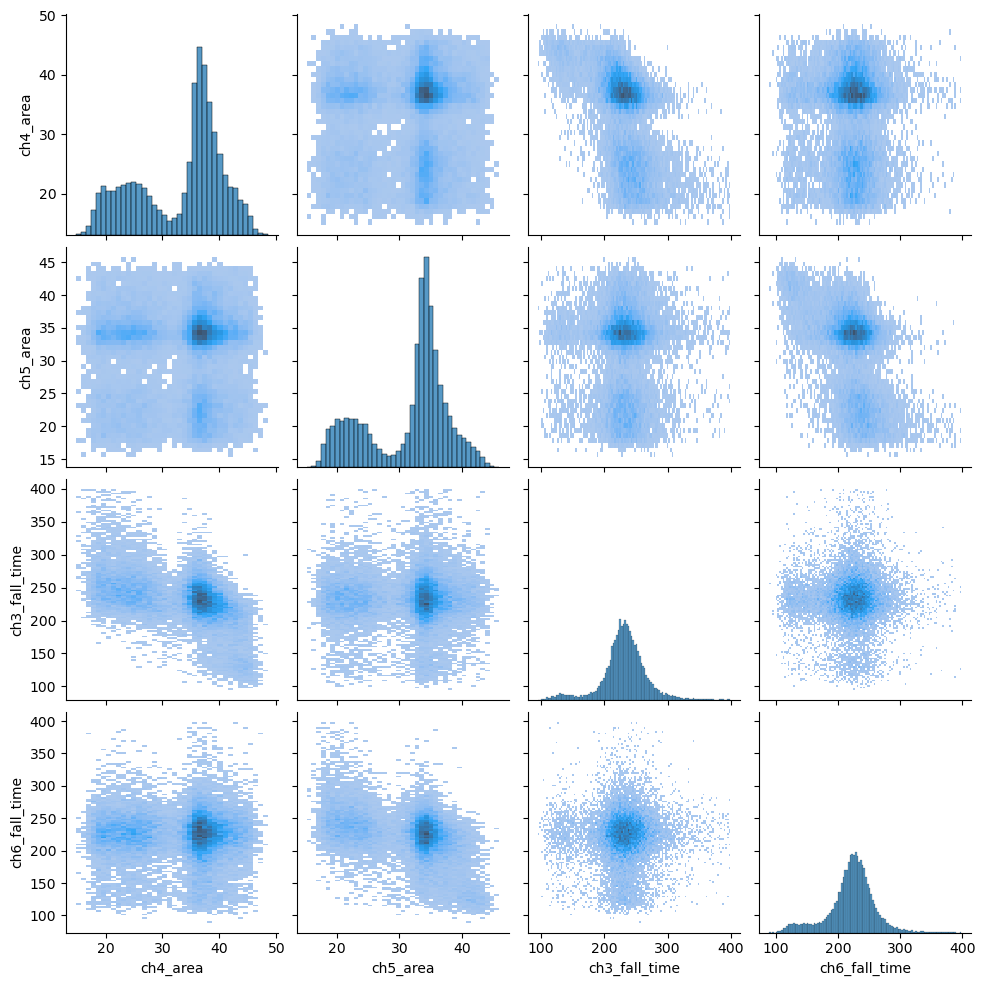

In [5]:
test = photo_cut[photo_cut["ch4_area"]>40]

# dff = df.copy()
# Filter out areas that are too large
dff = dff[(dff["ch4_area"]<50)&(dff["ch5_area"]<46)]
# dff = dff[(dff["ch5_area"]>30)&(dff["ch5_area"]<40)]
# dff = dff[(dff["ch4_area"]>18)&(dff["ch5_area"]<40)]

# dff = dff[(dff["ch4_min"]>100)&(dff["ch4_min"]<550)]
# dff = dff[(dff["ch5_min"]>100)&(dff["ch5_min"]<520)]

# Filter out delay times that are too large
dff = dff[(np.abs(dff["ch36_delay_time"])<500)]

# Filter out saturated fall times THIS IS THE RISE TIME
# dff = dff[(dff["ch3_fall_time"]<1000)&(dff["ch6_fall_time"]<280)]
# dff = dff[(dff["ch3_fall_time"]<1000)&(dff["ch3_fall_time"]<600)&(dff["ch6_fall_time"]<1000)&(dff["ch6_fall_time"]>160)]

# Filter out noise via rms
# dff = dff[(dff["ch3_rms"]<0.0015)&(dff["ch3_rms"]>0.001)]
# dff = dff[(dff["ch6_rms"]<0.0020)&(dff["ch6_rms"]>0.001)]
print(len(dff))
plt.figure()
sns.pairplot(dff[[
                    "ch4_area",
                    "ch5_area",
                    "ch3_fall_time",
                    "ch6_fall_time",
                    # "ch3_rms",
                    # "ch6_rms",
                    # "ch4_min",
                    # "ch36_delay_time"
                    ]], kind = "hist")
# sns.histplot(test["ch4_min"], stat = 'density')
# sns.histplot(photo_cut[photo_cut["ch4_area"]>0]["ch4_min"], stat = 'density')
plt.show()

46571


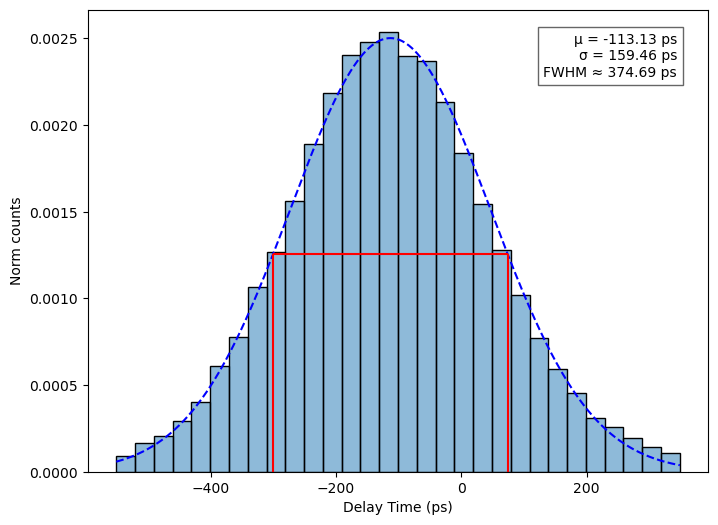

In [6]:
# DT cut
# print(len(photo_cut))
dt_cut = df[np.abs(df["ch36_delay_time"]+101) < 450]
print(len(dt_cut))

data = dt_cut["ch36_delay_time"]

# Fit Gaussian
mu, std = norm.fit(data)

# Generate x values for PDF
x = np.linspace(min(data), max(data), 1000)
pdf = norm.pdf(x, mu, std)

fig, ax = plt.subplots(1,1, figsize = (8,6))

sns.histplot(dt_cut["ch36_delay_time"],stat = 'density',bins = 30, alpha  = 0.5)

# Plot fitted curve
ax.plot(x, pdf, 'b--', label=f'Fit: μ={mu:.2f}, σ={std:.2f}', lw = 1.5)

# FWHM calculation
x_gt = x[pdf>=max(pdf)/2]
fwhm = x_gt[-1]-x_gt[0]
ax.vlines([x_gt[0],x_gt[-1]],0, pdf[pdf>=max(pdf)/2][0],"r")
ax.hlines(pdf[pdf>=max(pdf)/2][0],x_gt[0],x_gt[-1],"r")
# fwhm = 2*np.sqrt(2*np.log(2)) * std
ax.text(0.95, 0.95, f'μ = {mu:.2f} ps\nσ = {std:.2f} ps\nFWHM ≈ {fwhm:.2f} ps', transform=ax.transAxes,ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

# Labels and title
# ax.set_title(title)
ax.set_xlabel('Delay Time (ps)')
ax.set_ylabel('Norm counts')
# ax.legend()

plt.savefig("CTR_LYSO_LYSO.svg")
plt.show()

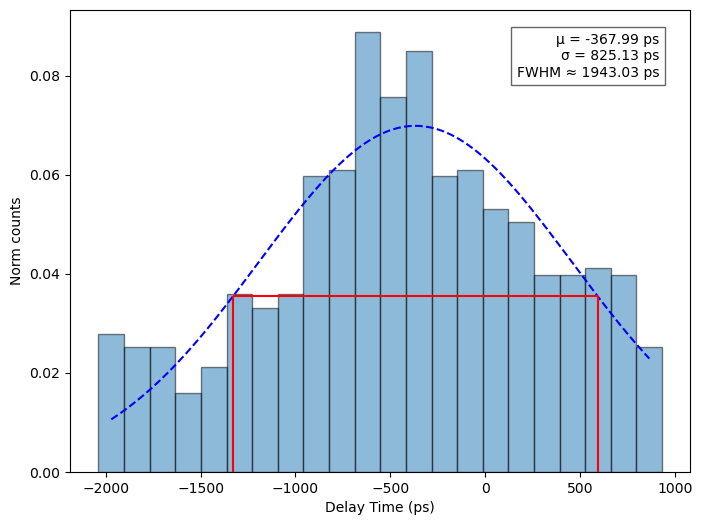

In [7]:
from scipy.optimize import curve_fit

dt = pd.read_csv("lyso_cds23B/dt.csv")

data_uct = dt[(dt["X: (s)"]+0.5e-9).abs()<1.5e-9]
# data_uct = dt

# Fit Gaussian
def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))

xs = data_uct["X: (s)"].to_numpy()*1e12
ys = data_uct["Y: (Hits)"].to_numpy()
ys = ys/sum(ys)
x = np.linspace(min(xs),max(xs),200)

po = [1,470,1000]
popt, pcov = curve_fit(gaussian, xs, ys, p0 = po)
pdf = gaussian(x, *popt)
# Generate x values for PDF
fig, ax = plt.subplots(1,1, figsize = (8,6))

# Plot fitted curve
# ax.plot(xs, data_uct["Y: (Hits)"].astype(float), drawstyle = "steps-mid")
ax.bar(x = xs, height = ys, edgecolor = "k", width = xs[1]-xs[0], alpha = 0.5)
ax.plot(x, pdf, 'b--', label=f'Fit: μ={popt[1]:.2f}, σ={popt[2]:.2f}', lw = 1.5)

mu = popt[1]
std = abs(popt[2])
# FWHM calculation
x_gt = x[pdf>=max(pdf)/2]
# fwhm = x_gt[-1]-x_gt[0]
ax.vlines([x_gt[0],x_gt[-1]],0, pdf[pdf>=max(pdf)/2][0],"r")
ax.hlines(pdf[pdf>=max(pdf)/2][0],x_gt[0],x_gt[-1],"r")
fwhm = 2*np.sqrt(2*np.log(2)) * std
ax.text(0.95, 0.95, f'μ = {mu:.2f} ps\nσ = {std:.2f} ps\nFWHM ≈ {fwhm:.2f} ps', transform=ax.transAxes,ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

# Labels and title
# ax.set_title(title)
ax.set_xlabel('Delay Time (ps)')
ax.set_ylabel('Norm counts')
# ax.legend()

plt.savefig("CTR_LYSO_CDS23B_UCT.svg")
plt.show()


## CTR Threshold Opt
 - 6 mV     ->  238.56 ps
 - 10 mV    ->  246.87 ps
 - 15 mV    ->  240.83 ps
 - 20 mV    ->  250.84 ps

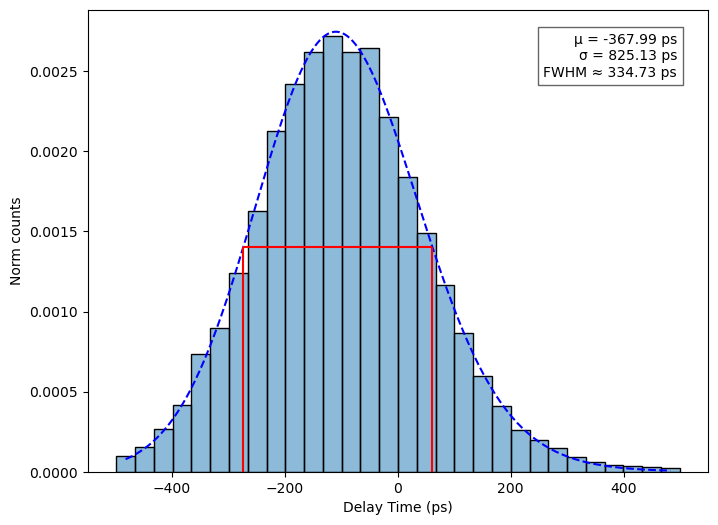

Fitted parameters:
Mu = -427.392
Sigma = 265.260
Tau = 67.723


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erfc
from scipy.integrate import simpson  # for numerical integration

# Exponentially modified Gaussian (EMG)
def exp_gauss(x, amplitude, mu, sigma, tau):
    """
    Exponentially modified Gaussian distribution:
    convolution of a Gaussian and an exponential decay.
    
    Parameters:
        x : array-like
        amplitude : scale factor
        mu : mean of the Gaussian
        sigma : std dev of the Gaussian
        tau : decay constant of the exponential
        
    Returns:
        EMG function evaluated at x
    """
    arg1 = (sigma**2 - 2*tau*(x - mu)) / (2**0.5 * sigma * tau)
    return (amplitude * 0.5 / tau *
            np.exp((sigma**2 - 2*tau*(x - mu)) / (2 * tau**2)) *
            erfc(arg1))

def normalized_exp_gauss(x, mu, sigma, tau):
    """Normalized EMG with area under curve = 1"""
    y = exp_gauss(x, 1.0, mu, sigma, tau)
    area = simpson(y, x)
    return y / area

# --- Generate synthetic data (optional) ---
np.random.seed(42)
x = np.linspace(0, 10, 200)
true_params = [4.0, 0.5, 1.0]  # mu, sigma, tau
y_true = normalized_exp_gauss(x, *true_params)
y = y_true + 0.02 * np.random.normal(size=len(x))

y, bins = np.histogram(dff["ch36_delay_time"], bins = 30)
y = np.array(y).astype(float)
x = bins[1:] - (bins[1]-bins[0])/2
x_fit = np.linspace(x[0],x[-1],200)
y /= simpson(y, x)

# --- Fit the EMG function to the noisy data ---
initial_guess = [-200, 20, 100]
popt, pcov = curve_fit(normalized_exp_gauss, x, y, p0=initial_guess)

# --- Plot the results ---
fig, ax = plt.subplots(1,1, figsize = (8,6))

sns.histplot(dff["ch36_delay_time"],stat = 'density',bins = 30, alpha  = 0.5)

# Plot fitted curve
y_fit = normalized_exp_gauss(x_fit, *popt)
ax.plot(x_fit, y_fit, 'b--', label=f'Fit', lw = 1.5)

# FWHM calculation
x_gt = x_fit[y_fit>=max(y_fit)/2]
fwhm = x_gt[-1]-x_gt[0]
ax.vlines([x_gt[0],x_gt[-1]],0, y_fit[y_fit>=max(y_fit)/2][0],"r")
ax.hlines(y_fit[y_fit>=max(y_fit)/2][0],x_gt[0],x_gt[-1],"r")
# fwhm = 2*np.sqrt(2*np.log(2)) * std
ax.text(0.95, 0.95, f'μ = {mu:.2f} ps\nσ = {std:.2f} ps\nFWHM ≈ {fwhm:.2f} ps', transform=ax.transAxes,ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.6))

# Labels and title
# ax.set_title(title)
ax.set_xlabel('Delay Time (ps)')
ax.set_ylabel('Norm counts')
# ax.legend()
plt.savefig("CTR_LYSO_GGAG.svg")
plt.show()

# Print fitted parameters
print(f"Fitted parameters:\nMu = {popt[0]:.3f}\nSigma = {popt[1]:.3f}\nTau = {popt[2]:.3f}")


In [ ]:
def emg_fwhm(amplitude, mu, sigma, tau, x_range=None):
    """
    Computes the FWHM of an exponentially modified Gaussian.

    Returns:
        approx_fwhm: Approximate FWHM using empirical formula
        numeric_fwhm: Numerical FWHM (optional, uses x_range)
    """
    # Approximate FWHM
    approx_fwhm = 2 * np.sqrt(2 * np.log(2)) * sigma + 1.76 * tau

    # Numerical FWHM (requires x_range)
    numeric_fwhm = None
    if x_range is not None:
        x_dense = np.linspace(x_range[0], x_range[1], 10000)
        y = exp_gauss(x_dense, amplitude, mu, sigma, tau)
        half_max = np.max(y) / 2.0
        indices = np.where(y >= half_max)[0]
        if len(indices) > 1:
            numeric_fwhm = x_dense[indices[-1]] - x_dense[indices[0]]

    return approx_fwhm, numeric_fwhm
